# SepsisGuard — GRPO Training Notebook

Train 4 multi-agent roles (Nurse, Lab, Pharmacist, Physician) using TRL GRPO with Unsloth 4-bit quantization.

This notebook:
1. Loads a quantized Qwen 2.5-3B model
2. Connects to the live SepsisGuard environment
3. Collects initial rollouts for the prompt dataset
4. Runs GRPO training with online environment rewards
5. Evaluates and plots reward improvement vs heuristic baseline

In [2]:
!pip install -q -U "unsloth[colab-new]" openenv-core "trl>=0.12" vllm datasets matplotlib
!pip install -q requests httpx

In [2]:
from unsloth import FastLanguageModel

MODEL_NAME = "unsloth/Qwen2.5-3B-Instruct-bnb-4bit"
model, tokenizer = FastLanguageModel.from_pretrained(
    MODEL_NAME, max_seq_length=4096, load_in_4bit=True,
)
model = FastLanguageModel.get_peft_model(
    model,
    r=16, lora_alpha=16, lora_dropout=0,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                     "gate_proj", "up_proj", "down_proj"],
)
FastLanguageModel.for_inference(model)
print(f"Model loaded: {MODEL_NAME}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 4.57.6. vLLM: 0.19.1.
   \\   /|    NVIDIA A10G. Num GPUs = 1. Max memory: 22.301 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.05G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.36k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

unsloth/Qwen2.5-3B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.4.8 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


Model loaded: unsloth/Qwen2.5-3B-Instruct-bnb-4bit


In [ ]:
#cloning hf space and running server locally to reduce latency while training
import os
import sys

# Define a relative folder name instead of an absolute Colab path
repo_folder = "sepsisguard"

# 1. Clone if it doesn't exist in the current directory
if not os.path.exists(repo_folder):
    !git clone https://huggingface.co/spaces/Jishnu-Vijayan-03/Sepsis-Guard sepsisguard

# 2. Change into the newly cloned directory
os.chdir(repo_folder)

# 3. Add the current directory (which is now sepsisguard) to sys.path
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

# 4. Install the package
!pip install -q -e .

# 5. Verify
print("Repo ready:", os.listdir("."))

Cloning into 'sepsisguard'...
remote: Enumerating objects: 146, done.
remote: Counting objects: 100% (142/142), done.
remote: Compressing objects: 100% (139/139), done.
remote: Total 146 (delta 82), reused 0 (delta 0), pack-reused 4 (from 1)
Receiving objects: 100% (146/146), 413.06 KiB | 13.77 MiB/s, done.
Resolving deltas: 100% (82/82), done.
Repo ready: ['.git', '.claude', '.env.example', '.gitattributes', '.gitignore', 'CLAUDE.md', 'Dockerfile', 'README.md', 'agents', 'inference.py', 'models.py', 'openenv.yaml', 'pyproject.toml', 'requirements.txt', 'server', 'tests', 'training', 'uv.lock']


In [6]:
import os
import signal
import subprocess
import time
import requests
import sys

# Dynamically get the current directory (should be your sepsisguard folder)
REPO_DIR = os.getcwd()
LOG_PATH = os.path.join(REPO_DIR, "uvicorn.log")

PORT = 8000
UVICORN_CMD = f"uvicorn server.app:app --host 0.0.0.0 --port {PORT}"
HEALTH_URL = f"http://127.0.0.1:{PORT}/health"

def _find_server_pids():
    proc = subprocess.run(
        ["pgrep", "-f", f"uvicorn server.app:app.*--port {PORT}"],
        capture_output=True, text=True
    )
    if proc.returncode != 0 or not proc.stdout.strip():
        return []
    return [int(x) for x in proc.stdout.strip().splitlines() if x.strip().isdigit()]

def _stop_existing_server():
    pids = _find_server_pids()
    if not pids:
        print("No existing SepsisGuard uvicorn process found on port", PORT)
        return
    print(f"Stopping existing uvicorn process(es): {pids}")
    for pid in pids:
        try:
            os.kill(pid, signal.SIGTERM)
        except OSError:
            pass
    time.sleep(1.5)
    
    survivors = _find_server_pids()
    for pid in survivors:
        try:
            os.kill(pid, signal.SIGKILL)
        except OSError:
            pass

def _start_server():
    # Write the log file to the dynamic current directory
    log_file = open(LOG_PATH, "w")
    
    subprocess.Popen(
        [sys.executable, "-m", "uvicorn", "server.app:app", "--host", "0.0.0.0", "--port", str(PORT)],
        stdout=log_file,
        stderr=log_file,
        cwd=REPO_DIR # Start the server in the dynamic current directory
    )

def _wait_for_health(timeout_s=15):
    t0 = time.time()
    while time.time() - t0 < timeout_s:
        try:
            r = requests.get(HEALTH_URL, timeout=3)
            if r.ok:
                return True
        except Exception:
            pass
        time.sleep(1)
    return False

_stop_existing_server()
print("Starting server...")
_start_server()

if _wait_for_health(timeout_s=15):
    print(f"✅ Local SepsisGuard server is healthy at http://127.0.0.1:{PORT}")
    print(f"📄 Log file created at: {LOG_PATH}")
else:
    print("❌ Server started but health check failed. Here is the crash log:")
    print("-" * 40)
    with open(LOG_PATH, "r") as f:
        print(f.read())
    print("-" * 40)

No existing SepsisGuard uvicorn process found on port 8000
Starting server...
✅ Local SepsisGuard server is healthy at http://127.0.0.1:8000
📄 Log file created at: /data/sepsisguard/uvicorn.log


In [7]:
!curl "http://127.0.0.1:8000/health"

{"status":"healthy"}

In [7]:
import os, requests, time

# If notebook and server run on the SAME Colab VM, localhost works.
# If your server is outside Colab, set ENV_BASE_URL to a public tunnel URL.
ENV_URL = os.environ.get("ENV_BASE_URL", "http://127.0.0.1:8000")

class EnvClient:
    def __init__(self, base_url):
        self.base_url = base_url.rstrip("/")

    def reset(self, task_name, seed, session_id=None):
        headers = {"X-Session-Id": session_id} if session_id else {}
        r = requests.post(f"{self.base_url}/reset",
                          json={"task_name": task_name, "seed": seed},
                          headers=headers, timeout=30)
        r.raise_for_status()
        return r.json()

    def step(self, actions, session_id=None):
        headers = {"X-Session-Id": session_id} if session_id else {}
        r = requests.post(f"{self.base_url}/step",
                          json={"actions": actions},
                          headers=headers, timeout=30)
        r.raise_for_status()
        return r.json()

    def create_session(self):
        r = requests.post(f"{self.base_url}/session", timeout=10)
        r.raise_for_status()
        return r.json()["session_id"]

    def delete_session(self, session_id):
        try:
            requests.delete(f"{self.base_url}/session/{session_id}", timeout=5)
        except Exception:
            pass

# Wait briefly for server readiness so first /reset doesn't fail noisily.
ready = False
for _ in range(15):
    try:
        requests.get(f"{ENV_URL}/state", timeout=3).raise_for_status()
        ready = True
        break
    except Exception:
        time.sleep(1)
if not ready:
    raise RuntimeError(
        f"Server not reachable at {ENV_URL}. Start uvicorn or set ENV_BASE_URL to your reachable URL."
    )

env = EnvClient(ENV_URL)
info = env.reset(task_name="task1_textbook", seed=42)
print(f"Connected to {ENV_URL}")
print(f"Tick: {info['info']['tick']}, Roles: {list(info['observations'].keys())}")

Connected to http://127.0.0.1:8000
Tick: 1, Roles: ['nurse', 'lab', 'pharmacist', 'physician']


In [8]:
import os, sys, json
from tqdm.auto import tqdm
# sys.path.insert(0, "/data/sepsisguard")

from training.prompts import build_role_prompt
from agents.nurse import HeuristicNurse
from agents.lab import HeuristicLab
from agents.pharmacist import HeuristicPharmacist
from agents.physician import HeuristicPhysician

ROLES = ("nurse", "lab", "pharmacist", "physician")

# --- BIGGEST CHANGE: Generate way more data for a 1500-step run ---
N_EPISODES = 50  # Jump from 16 to 100. This will generate ~10,000+ unique prompts.
SEEDS = list(range(42, 42 + N_EPISODES))
TASK = "task1_textbook"
MAX_TICKS_PER_EP = 48

heuristic_agents = {
    "nurse": HeuristicNurse(),
    "lab": HeuristicLab(),
    "pharmacist": HeuristicPharmacist(),
    "physician": HeuristicPhysician(),
}

print(f"Collecting prompts via {N_EPISODES} heuristic episodes...")
rollouts = []

for ep_idx, seed in enumerate(tqdm(SEEDS, desc="Episodes")):
    sid = env.create_session()
    bundle = env.reset(task_name=TASK, seed=seed, session_id=sid)
    done = False
    tick = 0

    while not done and tick < MAX_TICKS_PER_EP:
        obs = bundle["observations"]
        actions = {}
        for role in ROLES:
            prompt = build_role_prompt(obs[role], role)
            actions[role] = heuristic_agents[role].decide(obs[role])
            
            # --- OPTIONAL FILTERING ---
            # You can optionally skip adding prompts where nothing is happening
            # to keep the dataset dense with action. But for RL, seeing "quiet" 
            # states is also helpful. I'd leave it as is.
            rollouts.append({"prompt": prompt, "role": role, "seed": seed, "tick": tick + 1})
            
        bundle = env.step(actions, session_id=sid)
        done = bool(bundle.get("done", False))
        tick += 1

    env.delete_session(sid)

print(f"\nCollected {len(rollouts)} prompts from {N_EPISODES} episodes")
print(f"Roles: {set(r['role'] for r in rollouts)}")
print(f"Avg ticks/episode: {len(rollouts) / N_EPISODES / len(ROLES):.0f}")

Episodes:   0%|          | 0/50 [00:00<?, ?it/s]


Collected 9600 prompts from 50 episodes
Roles: {'nurse', 'physician', 'pharmacist', 'lab'}
Avg ticks/episode: 48


In [9]:
import json
import requests
import re
import torch
from datasets import Dataset
from tqdm.auto import tqdm
from training.prompts import build_role_prompt

# =====================================================================
# 1. DATA DEDUPLICATION & PREP
# =====================================================================
def get_clinical_state(prompt_str):
    """Strips out tick counters and rewards to find the true clinical state for dedup."""
    try:
        obs_start = prompt_str.find('Observation:\n') + 13
        obs_end = prompt_str.rfind('\nAction (JSON):')
        if obs_start < 13 or obs_end == -1: return prompt_str
        obs_json_str = prompt_str[obs_start:obs_end]
        obs_dict = json.loads(obs_json_str)
        for key in ["tick", "reward", "cumulative_reward", "last_action_result",
                     "normalized_score", "done", "metadata"]:
            obs_dict.pop(key, None)
        clean_obs_str = json.dumps(obs_dict, sort_keys=True)
        return prompt_str[:obs_start] + clean_obs_str + prompt_str[obs_end:]
    except Exception:
        return prompt_str

unique_prompts = {}
for r in rollouts:
    core_state = get_clinical_state(r["prompt"])
    if core_state not in unique_prompts:
        unique_prompts[core_state] = r["prompt"]

train_dataset = Dataset.from_list([{"prompt": p} for p in unique_prompts.values()])

print(f"Original rollouts: {len(rollouts)}")
print(f"Unique clinical scenarios: {len(unique_prompts)}")


Original rollouts: 9600
Unique clinical scenarios: 6558


In [ ]:
def make_llm_agent_fn(model, tokenizer, target_role):
    def agent_fn(role, obs):
        if role != target_role:
            return heuristic_agents_eval[role].decide(obs)
        prompt = build_role_prompt(obs, role)
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=256, do_sample=False)
        text = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
        try:
            parsed = json.loads(text.strip())
            if isinstance(parsed, dict) and "operation" in parsed: return parsed
        except Exception: pass
        match = re.search(r'\{.*?\}', text, re.DOTALL)
        if match:
            try:
                parsed = json.loads(match.group(0))
                if isinstance(parsed, dict) and "operation" in parsed: return parsed
            except Exception: pass
        return heuristic_agents_eval[role].decide(obs)
    return agent_fn

def run_episode(env_client, task_name, seed, agent_fn, session_id=None):
    bundle = env_client.reset(task_name=task_name, seed=seed, session_id=session_id)
    done = False
    while not done:
        obs = bundle["observations"]
        actions = {role: agent_fn(role, obs[role]) for role in ("nurse", "lab", "pharmacist", "physician")}
        bundle = env_client.step(actions, session_id=session_id)
        done = bundle["done"]
    grader = requests.get(f"{env_client.base_url}/grader",
                          headers={"X-Session-Id": session_id} if session_id else {},
                          timeout=30).json()
    return grader.get("score", 0.0)

nurse_h, lab_h, pharma_h, phys_h = HeuristicNurse(), HeuristicLab(), HeuristicPharmacist(), HeuristicPhysician()
def heuristic_agent_fn(role, obs):
    return heuristic_agents_eval[role].decide(obs)
heuristic_agents_eval = {"nurse": nurse_h, "lab": lab_h, "pharmacist": pharma_h, "physician": phys_h}

In [10]:
# =====================================================================
# BYPASS PRE-EVALUATION: HARDCODED BASELINES
# =====================================================================

# 1. The seeds used for evaluation
N_EVAL = 5
EVAL_SEEDS = list(range(100, 100 + N_EVAL))

# 2. Heuristic baseline scores
pre_baseline_scores = [0.938, 0.95, 0.775, 0.938, 0.487]

# 3. Pre-train LLM scores for each role
pre_trained_scores = {

    "nurse":      [0.938, 0.95, 0.487, 0.938, 0.45],

    "lab":        [0.7, 0.275, 0.487, 0.25, 0.287],

    "pharmacist": [0.738, 0.95, 0.487, 0.688, 0.487],

    "physician":  [0.938, 0.95, 0.475, 0.938, 0.475]

}

print("✅ Pre-evaluation baselines successfully loaded into memory.")

✅ Pre-evaluation baselines successfully loaded into memory.


In [ ]:
# import requests, json, re, torch
# from tqdm.auto import tqdm

# # =====================================================================
# # ⚠️ WARNING: EXTREMELY TIME-CONSUMING CELL ⚠️
# # =====================================================================
# print("🚨 WARNING: LIVE PRE-EVALUATION INITIATED 🚨")
# print("Running inference on the base un-finetuned model takes roughly 30-40 minutes.")
# print("If you are just tweaking hyperparameters or testing, STOP this cell now")
# print("and run the 'BYPASS PRE-EVALUATION: HARDCODED BASELINES' cell instead!")
# print("=====================================================================\n")

# # 1. The seeds used for evaluation
# N_EVAL = 5
# EVAL_SEEDS = list(range(100, 100 + N_EVAL))

# print("============================================================")
# print("PRE-TRAINING BASELINE EVALUATION")
# print("============================================================")

# # --- 1. Heuristic Baseline Evaluation (No LLMs, Pure Logic) ---
# print("\nRunning Pure Heuristic Baseline Evaluation...")
# pre_baseline_scores = []

# for seed in tqdm(EVAL_SEEDS, desc="Heuristic Baseline"):
#     sid = env.create_session()
#     # Passing None for the agent function uses the default heuristic for all 4 roles
#     score = run_episode(env, "task1_textbook", seed, heuristic_agent_fn, session_id=sid)
#     pre_baseline_scores.append(score)
#     env.delete_session(sid)

# heuristic_mean = sum(pre_baseline_scores) / len(pre_baseline_scores)
# print(f"Heuristic Baseline: mean={heuristic_mean:.4f}  scores={[round(s,3) for s in pre_baseline_scores]}")


# # --- 2. Pre-Train LLM Evaluation (Base Model, Per-Role) ---
# # Ensure model is in inference mode before evaluating
# FastLanguageModel.for_inference(model)

# pre_trained_scores = {}

# for target_role in ("nurse", "lab", "pharmacist", "physician"):
#     print(f"\nRunning Pre-train LLM Evaluation for: [ {target_role.upper()} ]")
    
#     # Create an agent function where the LLM plays 'target_role', heuristics play the rest
#     llm_fn = make_llm_agent_fn(model, tokenizer, target_role)
#     scores = []
    
#     for seed in tqdm(EVAL_SEEDS, desc=f"{target_role.capitalize()} Pre-train"):
#         sid = env.create_session()
#         score = run_episode(env, "task1_textbook", seed, llm_fn, session_id=sid)
#         scores.append(score)
#         env.delete_session(sid)
        
#     pre_trained_scores[target_role] = scores
#     role_mean = sum(scores) / len(scores)
#     print(f"Pre-train [{target_role}]: mean={role_mean:.4f}  scores={[round(s,3) for s in scores]}")

# print("\n" + "=" * 60)
# print("✅ Live Pre-evaluation complete. Baselines loaded into memory.")
# print("=" * 60)

In [11]:
import torch
import json
import re
import requests
from trl import GRPOTrainer, GRPOConfig
from transformers import TrainerCallback
from training.reward_shaping import make_online_sepsis_reward_fn, format_reward_fn

FastLanguageModel.for_training(model)

# --- 1. HARDWARE SETUP ---
has_cuda = torch.cuda.is_available()
if has_cuda:
    major, _ = torch.cuda.get_device_capability()
    use_bf16 = major >= 8
    use_fp16 = not use_bf16
    print(f"CUDA device: {torch.cuda.get_device_name(0)} | bf16={use_bf16} fp16={use_fp16}")
else:
    use_bf16 = False
    use_fp16 = False
    print("CUDA not available. Using fp32 precision.")

# --- 2. GRPO CONFIGURATION ---
cfg = GRPOConfig(
    output_dir="./sepsis-grpo-v3",
    num_generations=8,                   # Back to 8 for better gradient quality
    per_device_train_batch_size=2,       
    gradient_accumulation_steps=4,       
    max_steps=450,                       # Short, intense burst to fix the behavior
    learning_rate=2e-5,                  # Higher LR to break the "noop" habit
    warmup_steps=30,
    logging_steps=5,
    save_steps=150,
    max_prompt_length=3000,
    max_completion_length=128,
    temperature=1.0,                     # Bumping to 1.0 to force more exploration
    bf16=True,                           
    fp16=False,
    report_to="none",
    gradient_checkpointing=True,
)

# --- 3. REWARD FUNCTIONS ---                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
reward_fn_env_obj = make_online_sepsis_reward_fn(                                                                                                                                                                                                                                                                                                                                                                                                                         
    env_url=ENV_URL,                                                                                                                                                                                                                                                                                                                                                                                                                                                      
    task_name=TASK,                                                                                                                                                                                                                                                                                                                                                                                                                                                       
    seed=42,                                                                                                                                                                                                                                                                                                                                                                                                                                                              
    warmup_ticks=3,                                                                                                                                                                                                                                                                                                                                                                                                                                                       
    inject_ticks=4,                                                                                                                                                                                                                                                                                                                                                                                                                                                       
    max_workers=3,                                                                                                                                                                                                                                                                                                                                                                                                                                                        
)                                                                                                                                                                                                                                                                                                                                                                                                                                                                         
                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
# print("=" * 60)                                                                                                                                                                                                                                                                                                                                                                                                                                                           
# print("PRE-FLIGHT REWARD CHECK")                                                                                                                                                                                                                                                                                                                                                                                                                                          
# print("=" * 60)                                                                                                                                                                                                                                                                                                                                                                                                                                                           
# passed = reward_fn_env_obj.preflight_check()                                                                                                                                                                                                                                                                                                                                                                                                                              
# print("=" * 60)   

def reward_fn_env(*args, **kwargs):
    return reward_fn_env_obj(*args, **kwargs)
reward_fn_env.__name__ = "reward_fn_env"

reward_log = {"steps": [], "env_reward": [], "format_reward": [], "combined_reward": []}

# --- 4. QUIET REWARD LOGGER ---
class RewardLogger(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs:
            return
        step = state.global_step

        # Silently capture rewards for plotting later
        env_r = logs.get("rewards/reward_fn_env/mean") or logs.get("reward_fn_env", 0.0)
        fmt_r = logs.get("rewards/format_reward_fn/mean") or logs.get("format_reward_fn", 0.0)
        combined = logs.get("reward", env_r + fmt_r)

        if env_r != 0.0 or fmt_r != 0.0 or "reward" in logs:
            reward_log["steps"].append(step)
            reward_log["env_reward"].append(float(env_r))
            reward_log["format_reward"].append(float(fmt_r))
            reward_log["combined_reward"].append(float(combined))


trainer = GRPOTrainer(
    model=model,
    reward_funcs=[reward_fn_env, format_reward_fn],
    args=cfg,
    train_dataset=train_dataset,
    callbacks=[RewardLogger()],
)

print(f"Training: {cfg.max_steps} steps, lr={cfg.learning_rate}, "
      f"batch={cfg.per_device_train_batch_size}x{cfg.gradient_accumulation_steps}, "
      f"gen={cfg.num_generations}, grad_ckpt={cfg.gradient_checkpointing}")
print(f"Dataset: {len(train_dataset)} unique prompts")
print("Starting GRPO training...")
trainer.train()
print("Training complete.")

CUDA device: NVIDIA A10G | bf16=True fp16=False
Training: 450 steps, lr=2e-05, batch=2x4, gen=8, grad_ckpt=True
Dataset: 6558 unique prompts
Starting GRPO training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 6,558 | Num Epochs = 1 | Total steps = 450
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)


Unsloth: Will smartly offload gradients to save VRAM!
[REWARD call=1] mean=-1.500 min=-1.500 max=-1.500 zeros=0/8 noops=8 env_evals=0 roles={'nurse': 8}
  [NOOP idx=0] role=nurse op=noop len=2 → -1.5
  [NOOP idx=1] role=nurse op=noop len=2 → -1.5
  [NOOP idx=2] role=nurse op=noop len=2 → -1.5
  [NOOP idx=3] role=nurse op=noop len=2 → -1.5
  [NOOP idx=4] role=nurse op=noop len=2 → -1.5
  [NOOP idx=5] role=nurse op=noop len=2 → -1.5
  [NOOP idx=6] role=nurse op=noop len=2 → -1.5
  [NOOP idx=7] role=nurse op=noop len=2 → -1.5
[COLLAPSE WARN call=1] 8/8 completions are noops — model may be collapsing. Check step sample output.


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_fn_env / mean,rewards / reward_fn_env / std,rewards / format_reward_fn / mean,rewards / format_reward_fn / std
5,-0.064000,-1.090000,0.198710,11.150000,7.000000,17.800000,0.000000,11.150000,7.000000,17.800000,0.000000,-1.200000,0.192725,0.110000,0.007559
10,-0.140400,-0.700000,0.585039,34.975000,16.200000,58.400000,0.025000,33.025001,16.200000,49.600000,0.003112,-0.840000,0.550751,0.140000,0.048391
15,-0.084800,-1.131250,0.244649,14.000000,8.000000,24.800000,0.000000,14.000000,8.000000,24.800000,0.001998,-1.242500,0.231871,0.111250,0.012794
20,-0.232000,-1.163750,0.376779,17.000000,7.400000,47.800000,0.000000,17.000000,7.400000,47.800000,0.001356,-1.277500,0.358144,0.113750,0.021610
25,-0.096200,-0.995000,0.309197,16.625000,9.600000,19.400000,0.000000,16.625000,9.600000,19.400000,0.004363,-1.112500,0.305066,0.117500,0.007071
30,-0.057600,-1.197500,0.168003,15.350000,9.600000,24.600000,0.000000,15.350000,9.600000,24.600000,0.032705,-1.317500,0.151351,0.120000,0.018150
35,-0.136500,-1.153750,0.114321,19.300000,11.000000,38.400000,0.000000,19.300000,11.000000,38.400000,0.009845,-1.280000,0.099714,0.126250,0.020861
40,-0.157900,-1.040000,0.033496,42.050000,27.600000,65.200000,0.000000,42.050000,27.600000,65.200000,0.105980,-1.215000,0.009258,0.175000,0.024238
45,-0.069500,-0.296250,0.655742,40.575000,25.400000,53.600000,0.000000,40.575000,25.400000,53.600000,0.089678,-0.472500,0.659461,0.176250,0.005175
50,0.107300,-0.385000,0.544346,46.450000,27.000000,66.200000,0.000000,46.450000,27.000000,66.200000,0.085200,-0.567500,0.551045,0.182500,0.012416


[REWARD call=2] mean=-1.500 min=-1.500 max=-1.500 zeros=0/8 noops=8 env_evals=0 roles={'nurse': 8}
  [NOOP idx=0] role=nurse op=noop len=2 → -1.5
  [NOOP idx=1] role=nurse op=noop len=2 → -1.5
  [NOOP idx=2] role=nurse op=noop len=2 → -1.5
  [NOOP idx=3] role=nurse op=noop len=2 → -1.5
  [NOOP idx=4] role=nurse op=noop len=2 → -1.5
  [NOOP idx=5] role=nurse op=noop len=2 → -1.5
  [NOOP idx=6] role=nurse op=noop len=2 → -1.5
  [NOOP idx=7] role=nurse op=noop len=2 → -1.5
[COLLAPSE WARN call=2] 8/8 completions are noops — model may be collapsing. Check step sample output.
[REWARD call=3] mean=0.000 min=-1.500 max=1.000 zeros=1/8 noops=2 env_evals=6 roles={'nurse': 8}
  [NOOP idx=0] role=nurse op=noop len=2 → -1.5
  [OK idx=1] role=nurse seed=19114 action=request_lab_test pid=P03 baseline=0.000 llm=0.300 adv=0.300 final=0.500 tick_rewards=[0.0, 0.0, 0.0, 0.3] warmup_early=0 inject_early=False
  [ZERO idx=2] role=nurse seed=19114 action=flag_concern pid=P01 baseline=0.000 llm=0.000 adv=0.0

...

[REWARD ERR] _run_window EXCEPTION seed=68813 role=nurse action={'operation': 'flag_concern', 'patient_id': 'P04', 'rationale': 'HR 84 borderline tachycardia, requesting lactate', 'urgency': 'high'}
  Error: 422 Client Error: Unprocessable Entity for url: http://127.0.0.1:8000/step
  Traceback:
Traceback (most recent call last):
  File "/data/sepsisguard/training/reward_shaping.py", line 249, in _run_window
    bundle = self._step(actions, session_id)
  File "/data/sepsisguard/training/reward_shaping.py", line 154, in _step
    r.raise_for_status()
  File "/home/user/miniconda/lib/python3.10/site-packages/requests/models.py", line 1028, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 422 Client Error: Unprocessable Entity for url: http://127.0.0.1:8000/step

[REWARD ERR] _run_window EXCEPTION seed=68813 role=nurse action={'operation': 'flag_concern', 'patient_id': 'P04', 'rationale': 'HR 84 borderline tachycardia, same as previous t

[training.reward_shaping|WARNING][OnlineSepsisReward] _run_window failed (seed=87192, role=nurse): 422 Client Error: Unprocessable Entity for url: http://127.0.0.1:8000/step


[REWARD ERR] _run_window EXCEPTION seed=87192 role=nurse action={'operation': 'flag_concern', 'patient_id': 'P01', 'rationale': 'HR 115 borderline tachycardia, PT 115, BP 94, RR 22, Temp 37.4, SpO2 99', 'urgency': 'immediate'}
  Error: 422 Client Error: Unprocessable Entity for url: http://127.0.0.1:8000/step
  Traceback:
Traceback (most recent call last):
  File "/data/sepsisguard/training/reward_shaping.py", line 249, in _run_window
    bundle = self._step(actions, session_id)
  File "/data/sepsisguard/training/reward_shaping.py", line 154, in _step
    r.raise_for_status()
  File "/home/user/miniconda/lib/python3.10/site-packages/requests/models.py", line 1028, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 422 Client Error: Unprocessable Entity for url: http://127.0.0.1:8000/step

[REWARD call=274] mean=0.000 min=0.000 max=0.000 zeros=8/8 noops=0 env_evals=8 roles={'nurse': 8}
  [ZERO idx=0] role=nurse seed=87192 action=flag_co

[training.reward_shaping|WARNING][OnlineSepsisReward] _run_window failed (seed=47655, role=nurse): 422 Client Error: Unprocessable Entity for url: http://127.0.0.1:8000/step


[REWARD ERR] _run_window EXCEPTION seed=47655 role=nurse action={'operation': 'flag_concern', 'patient_id': 'P03', 'rationale': 'Mild tachypnea, requesting ABG and PT/INR', 'urgency': 'moderate'}
  Error: 422 Client Error: Unprocessable Entity for url: http://127.0.0.1:8000/step
  Traceback:
Traceback (most recent call last):
  File "/data/sepsisguard/training/reward_shaping.py", line 249, in _run_window
    bundle = self._step(actions, session_id)
  File "/data/sepsisguard/training/reward_shaping.py", line 154, in _step
    r.raise_for_status()
  File "/home/user/miniconda/lib/python3.10/site-packages/requests/models.py", line 1028, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 422 Client Error: Unprocessable Entity for url: http://127.0.0.1:8000/step

[REWARD call=337] mean=-0.188 min=-1.500 max=0.000 zeros=7/8 noops=1 env_evals=7 roles={'nurse': 8}
  [ZERO idx=0] role=nurse seed=47655 action=flag_concern pid=P03 baseline=0.000 

In [12]:
import os

# --- 1. Define Paths ---
# Persistent Storage Paths
base_dir = "./sepsis-model"
lora_path = os.path.join(base_dir, "sepsis-grpo-v3-lora")       # NEW: Added -v2
merged_path = os.path.join(base_dir, "sepsis-grpo-v3-merged")   # NEW: Added -v2

# Ensure the base directory exists
os.makedirs(base_dir, exist_ok=True)

# --- 2. Save Directly to Persistent Storage ---
print(f"💾 Saving V3 LoRA adapters to {lora_path} ...")
model.save_pretrained(lora_path)
tokenizer.save_pretrained(lora_path)

print(f"💾 Saving V3 Merged 16-bit model to {merged_path} ...")
print("(This may take a few minutes...)")
model.save_pretrained_merged(
    merged_path,
    tokenizer,
    save_method="merged_16bit",
)

print(f"\n🎉 Success! V3 Models are securely saved to your persistent storage at {base_dir}.")

💾 Saving V3 LoRA adapters to /data/sepsis-model/sepsis-grpo-v3-lora ...
💾 Saving V3 Merged 16-bit model to /data/sepsis-model/sepsis-grpo-v3-merged ...
(This may take a few minutes...)
Found HuggingFace hub cache directory: /home/user/.cache/huggingface/hub
Checking cache directory for required files...


Unsloth: Copying 2 files from cache to `/data/sepsis-model/sepsis-grpo-v3-merged`: 100%|██████████| 2/2 [00:09<00:00,  4.63s/it]


Successfully copied all 2 files from cache to `/data/sepsis-model/sepsis-grpo-v3-merged`
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [00:22<00:00, 11.45s/it]


Unsloth: Merge process complete. Saved to `/data/sepsis-model/sepsis-grpo-v3-merged`

🎉 Success! V3 Models are securely saved to your persistent storage at /data/sepsis-model.


In [14]:
import requests, json, re, torch
from tqdm.auto import tqdm

FastLanguageModel.for_inference(model)

print("=" * 60)
print("POST-TRAINING EVALUATION")
print("=" * 60)

# --- Per-role evaluation (LLM replaces one role, heuristics for rest) ---
post_trained_scores = {}
for target_role in ("nurse", "lab", "pharmacist", "physician"):
    print(f"\nRunning Post-train LLM Evaluation for: [ {target_role.upper()} ]")
    llm_fn = make_llm_agent_fn(model, tokenizer, target_role)
    scores = []
    
    # WRAPPED IN TQDM HERE
    for seed in tqdm(EVAL_SEEDS, desc=f"{target_role.capitalize()} Progress"):
        sid = env.create_session()
        score = run_episode(env, "task1_textbook", seed, llm_fn, session_id=sid)
        scores.append(score)
        env.delete_session(sid)
        
    post_trained_scores[target_role] = scores
    pre_mean = sum(pre_trained_scores[target_role]) / len(pre_trained_scores[target_role])
    post_mean = sum(scores) / len(scores)
    delta = post_mean - pre_mean
    print(f"Post-train [{target_role}]: mean={post_mean:.4f}  delta_vs_pre={delta:+.4f}  scores={[round(s,3) for s in scores]}")


# --- Summary table ---
heuristic_mean = sum(pre_baseline_scores) / len(pre_baseline_scores)
print(f"\n{'Role':<15} {'Heuristic':>10} {'Pre-Train':>10} {'Post-Train':>10} {'Delta':>10}")
print("-" * 60)
for role in ("nurse", "lab", "pharmacist", "physician"):
    pre = sum(pre_trained_scores[role]) / len(pre_trained_scores[role])
    post = sum(post_trained_scores[role]) / len(post_trained_scores[role])
    delta = post - pre
    print(f"{role:<15} {heuristic_mean:>10.4f} {pre:>10.4f} {post:>10.4f} {delta:>+10.4f}")
print("=" * 60)

POST-TRAINING EVALUATION

Running Post-train LLM Evaluation for: [ NURSE ]


Nurse Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Post-train [nurse]: mean=0.8425  delta_vs_pre=+0.0899  scores=[0.938, 0.95, 0.9, 0.938, 0.487]

Running Post-train LLM Evaluation for: [ LAB ]


Lab Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Post-train [lab]: mean=0.6500  delta_vs_pre=+0.2502  scores=[0.738, 0.275, 0.575, 0.713, 0.95]

Running Post-train LLM Evaluation for: [ PHARMACIST ]


Pharmacist Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Post-train [pharmacist]: mean=0.7625  delta_vs_pre=+0.0925  scores=[0.938, 0.963, 0.487, 0.938, 0.487]

Running Post-train LLM Evaluation for: [ PHYSICIAN ]


Physician Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Post-train [physician]: mean=0.4500  delta_vs_pre=-0.3052  scores=[0.45, 0.45, 0.45, 0.45, 0.45]

Role             Heuristic  Pre-Train Post-Train      Delta
------------------------------------------------------------
nurse               0.8176     0.7526     0.8425    +0.0899
lab                 0.8176     0.3998     0.6500    +0.2502
pharmacist          0.8176     0.6700     0.7625    +0.0925
physician           0.8176     0.7552     0.4500    -0.3052


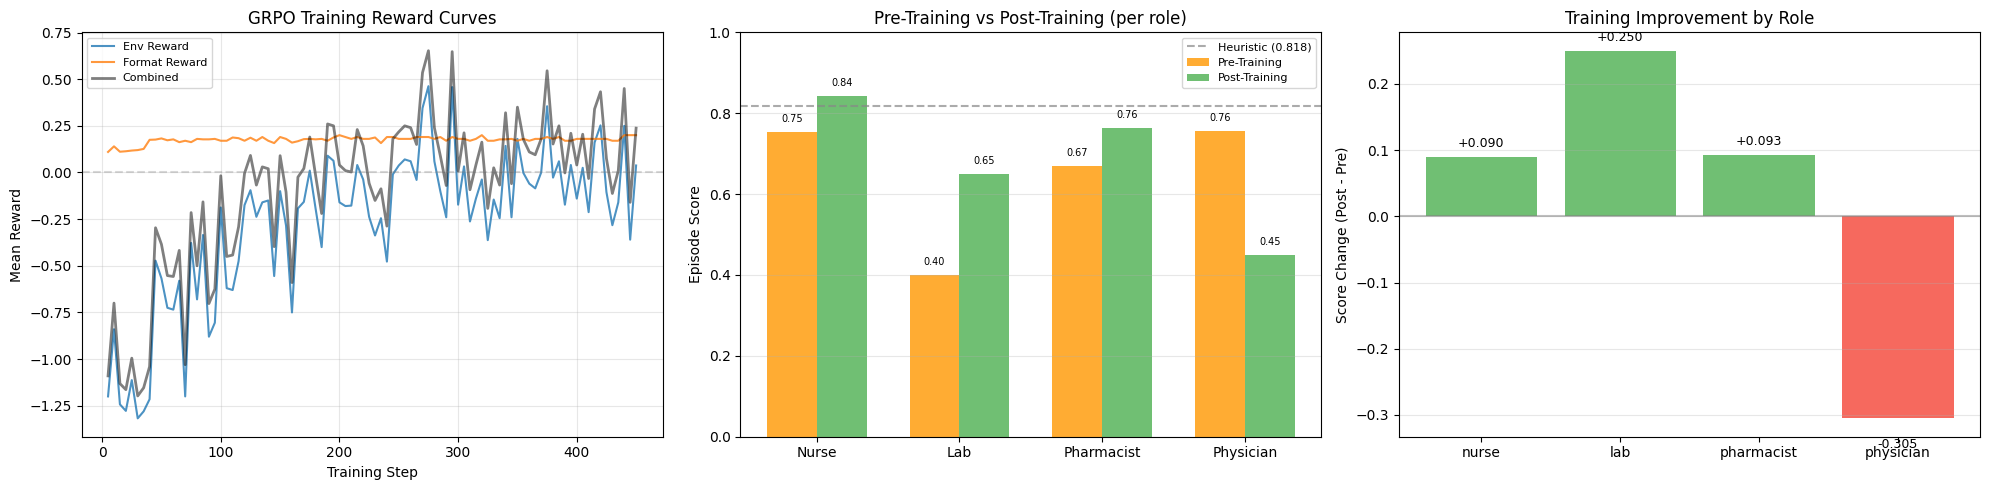

Plot saved to training_results.png


In [15]:
import matplotlib.pyplot as plt
import numpy as np

# --- SAFETY CATCH FOR MISSING VARIABLES ---
# If the kernel restarted, reward_log is gone. Let's gracefully handle it.
try:
    reward_log
except NameError:
    print("⚠️ Warning: 'reward_log' not found in memory. Skipping Panel 1 data.")
    reward_log = {"steps": [], "env_reward": [], "format_reward": [], "combined_reward": []}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# --- Panel 1: Reward Curves ---
if reward_log.get("steps"):
    axes[0].plot(reward_log["steps"], reward_log["env_reward"], label="Env Reward", linewidth=1.5, alpha=0.8)
    axes[0].plot(reward_log["steps"], reward_log["format_reward"], label="Format Reward", linewidth=1.5, alpha=0.8)
    if reward_log.get("combined_reward"):
        axes[0].plot(reward_log["steps"], reward_log["combined_reward"], label="Combined", linewidth=2, color="black", alpha=0.5)
    axes[0].axhline(y=0, color="gray", linestyle="--", alpha=0.3)
    axes[0].set_xlabel("Training Step")
    axes[0].set_ylabel("Mean Reward")
    axes[0].set_title("GRPO Training Reward Curves")
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5, "No reward logs captured\n(kernel restarted since training)",
                 ha="center", va="center", transform=axes[0].transAxes, fontsize=11)
    axes[0].set_title("GRPO Training Reward Curves")

# --- Panel 2: Before vs After (per role) ---
roles = ["nurse", "lab", "pharmacist", "physician"]
heuristic_mean = sum(pre_baseline_scores) / len(pre_baseline_scores)

pre_means = [sum(pre_trained_scores[r]) / len(pre_trained_scores[r]) for r in roles]
post_means = [sum(post_trained_scores[r]) / len(post_trained_scores[r]) for r in roles]

x = np.arange(len(roles))
width = 0.35
bars_pre = axes[1].bar(x - width/2, pre_means, width, label="Pre-Training", color="#FF9800", alpha=0.8)
bars_post = axes[1].bar(x + width/2, post_means, width, label="Post-Training", color="#4CAF50", alpha=0.8)
axes[1].axhline(y=heuristic_mean, color="#888888", linestyle="--", alpha=0.7, label=f"Heuristic ({heuristic_mean:.3f})")
axes[1].set_xticks(x)
axes[1].set_xticklabels([r.capitalize() for r in roles])
axes[1].set_ylabel("Episode Score")
axes[1].set_title("Pre-Training vs Post-Training (per role)")
axes[1].set_ylim(0, 1.0)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis="y")

for bar, val in zip(bars_pre, pre_means):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.2f}",
                 ha="center", va="bottom", fontsize=7)
for bar, val in zip(bars_post, post_means):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.2f}",
                 ha="center", va="bottom", fontsize=7)

# --- Panel 3: Delta improvement ---
deltas = [post - pre for post, pre in zip(post_means, pre_means)]
colors = ["#4CAF50" if d >= 0 else "#F44336" for d in deltas]
bars_d = axes[2].bar(roles, deltas, color=colors, alpha=0.8)
axes[2].axhline(y=0, color="gray", linestyle="-", alpha=0.5)
axes[2].set_ylabel("Score Change (Post - Pre)")
axes[2].set_title("Training Improvement by Role")
axes[2].grid(True, alpha=0.3, axis="y")
for bar, val in zip(bars_d, deltas):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 val + 0.01 if val >= 0 else val - 0.03,
                 f"{val:+.3f}", ha="center", va="bottom" if val >= 0 else "top", fontsize=9)

plt.tight_layout()
plt.savefig("training_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to training_results.png")

🔍 Attempting to recover logs from: ./sepsis-grpo-v3/checkpoint-450/trainer_state.json
✅ Successfully recovered 90 loss entries and 90 reward entries!


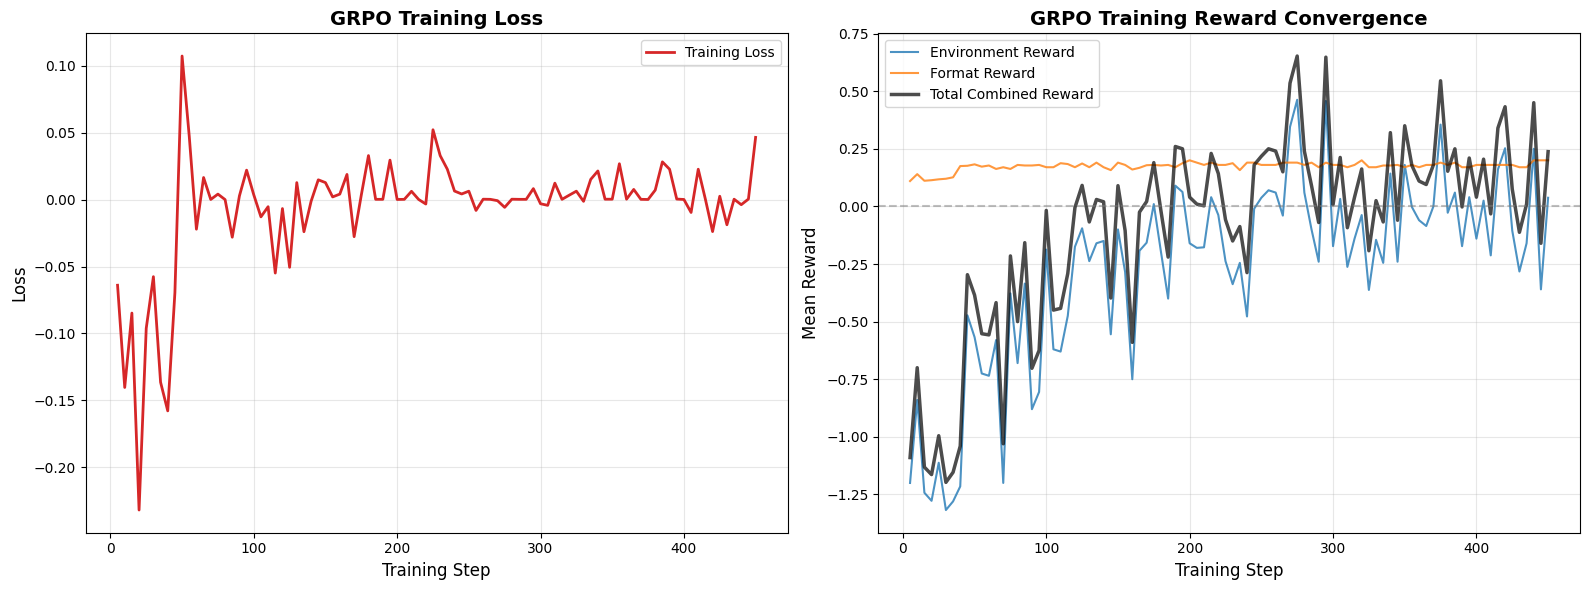

🎉 Plot saved to loss_and_reward_curves.png


In [6]:
import json
import matplotlib.pyplot as plt
import os

# --- 1. Point to your highest checkpoint folder ---
checkpoint_dir = "./sepsis-grpo-v3/checkpoint-450" 
state_path = os.path.join(checkpoint_dir, "trainer_state.json")

print(f"🔍 Attempting to recover logs from: {state_path}")

try:
    with open(state_path, "r") as f:
        state = json.load(f)
    
    # Separate lists because loss and rewards might log on slightly different steps
    loss_steps = []
    losses = []
    
    reward_steps = []
    env_rewards = []
    format_rewards = []
    combined_rewards = []
    
    # --- 2. Extract metrics from Hugging Face's log history ---
    for log in state.get("log_history", []):
        step = log.get("step")
        
        # Extract Loss
        if "loss" in log:
            loss_steps.append(step)
            losses.append(float(log["loss"]))
            
        # Extract Rewards
        env_r = log.get("rewards/reward_fn_env/mean")
        if env_r is None:
            env_r = log.get("reward_fn_env")
            
        fmt_r = log.get("rewards/format_reward_fn/mean")
        if fmt_r is None:
            fmt_r = log.get("format_reward_fn")
            
        if env_r is not None and fmt_r is not None:
            reward_steps.append(step)
            env_rewards.append(float(env_r))
            format_rewards.append(float(fmt_r))
            combined_rewards.append(float(env_r) + float(fmt_r))
            
    print(f"✅ Successfully recovered {len(loss_steps)} loss entries and {len(reward_steps)} reward entries!")

    # --- 3. Plot the Curves ---
    if reward_steps or loss_steps:
        # Create a side-by-side subplot layout
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # --- Panel 1: Loss Curve ---
        if loss_steps:
            ax1.plot(loss_steps, losses, label="Training Loss", linewidth=2, color="#d62728")
            ax1.set_xlabel("Training Step", fontsize=12)
            ax1.set_ylabel("Loss", fontsize=12)
            ax1.set_title("GRPO Training Loss", fontsize=14, fontweight="bold")
            ax1.legend(fontsize=10)
            ax1.grid(True, alpha=0.3)
        else:
            ax1.text(0.5, 0.5, "No Loss Data Found", ha='center', va='center', fontsize=12)
            ax1.set_title("GRPO Training Loss")

        # --- Panel 2: Reward Curve ---
        if reward_steps:
            ax2.plot(reward_steps, env_rewards, label="Environment Reward", linewidth=1.5, alpha=0.8, color="#1f77b4")
            ax2.plot(reward_steps, format_rewards, label="Format Reward", linewidth=1.5, alpha=0.8, color="#ff7f0e")
            ax2.plot(reward_steps, combined_rewards, label="Total Combined Reward", linewidth=2.5, color="black", alpha=0.7)

            ax2.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
            ax2.set_xlabel("Training Step", fontsize=12)
            ax2.set_ylabel("Mean Reward", fontsize=12)
            ax2.set_title("GRPO Training Reward Convergence", fontsize=14, fontweight="bold")
            ax2.legend(fontsize=10)
            ax2.grid(True, alpha=0.3)
        else:
            ax2.text(0.5, 0.5, "No Reward Data Found", ha='center', va='center', fontsize=12)
            ax2.set_title("GRPO Training Reward Convergence")
        
        # Final formatting
        plt.tight_layout()
        plt.savefig("loss_and_reward_curves.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("🎉 Plot saved to loss_and_reward_curves.png")
    else:
        print("⚠️ Could not find reward or loss metrics in the log history.")

except FileNotFoundError:
    print(f"❌ Error: Could not find {state_path}. Look inside your folder and update the 'checkpoint_dir' variable to match the highest checkpoint folder there!")